In [1]:
import pandas as pd
import numpy as np

In [2]:
import os

In [3]:
future_before_df = pd.read_csv("../data/before_future_train_v3.csv", index_col=0)
future_train_df = pd.read_csv("../data/future_train_v3.csv", index_col=0)
future_test_df = pd.read_csv("../data/future_test_v3.csv", index_col=0)

In [4]:
future_tot_train_df = pd.concat([future_before_df, future_train_df], axis=0)
future_tot_train_df.reset_index(drop=True, inplace=True)
future_tot_train_df = pd.concat([future_tot_train_df, future_test_df], axis=0)
future_tot_train_df.reset_index(drop=True, inplace=True)
future_tot_train_df.sort_values(by=['date', 'tic_code'], inplace=True)
future_tot_train_df.reset_index(drop=True, inplace=True)

In [5]:
before_df = pd.read_csv("../data/before_train_v3.csv", index_col=0)
train_df = pd.read_csv("../data/train_v3.csv", index_col=0)
test_df = pd.read_csv("../data/test_v3.csv", index_col=0)
tot_train_df = pd.concat([before_df, train_df], axis=0)
tot_train_df.reset_index(drop=True, inplace=True)
tot_train_df = pd.concat([tot_train_df, test_df], axis=0)
tot_train_df.reset_index(drop=True, inplace=True)
tot_train_df.sort_values(by=['date', 'tic_code'], inplace=True)
tot_train_df.reset_index(drop=True, inplace=True)

In [6]:
selected_feat = ['date', 'tic_code', 'close', 'ticker',
       'ret', 'high_ratio', 'low_ratio', 'adjust_close', 'adjust_high',
       'adjust_low', 'return_1m', 'return_3m', 'return_6m', 'return_12m',
       'return_avg', 'mom_12m', 'mom_score', 'close_1_month', 'close_2_month',
       'close_3_month', 'close_4_month', 'close_5_month', 'close_6_month',
       'close_7_month', 'close_8_month', 'close_9_month', 'close_10_month',
       'close_11_month', 'close_12_month', 'SMA_30', 'SMA_60', 'SMA_220',
       'SMA_252', 'macd', 'boll_ub', 'boll_lb', 'rsi', 'cci', 'paa_score',
       'gtaa_buy_signal', 'paa_buy_signal', 'daa_buy_signal',
       'momentum_product', 'dm_buy_signal', 'adjust_close_norm',
       'return_1m_norm', 'return_3m_norm', 'return_6m_norm', 'return_12m_norm',
       'return_avg_norm', 'mom_12m_norm', 'mom_score_norm', 'SMA_30_norm',
       'SMA_60_norm', 'SMA_220_norm', 'SMA_252_norm', 'macd_norm',
       'boll_ub_norm', 'boll_lb_norm', 'rsi_norm', 'cci_norm']

In [7]:
eqaul_df = pd.concat([tot_train_df[selected_feat], future_tot_train_df[selected_feat]])

In [8]:
eqaul_df.sort_values(by=['date', 'tic_code'], inplace=True)
eqaul_df.reset_index(drop=True, inplace=True)

In [9]:
# TRAIN_END_DATE = '2008-12-31'

In [10]:
# tot_train_df = tot_train_df[tot_train_df["date"] > TRAIN_END_DATE]

In [11]:
# tot_train_df.reset_index(drop=True, inplace=True)

In [12]:


TRAIN_START_DATE = '2001-01-10'
TRAIN_END_DATE = '2009-12-31'
TRADE_START_DATE = '2010-01-01'
TRADE_END_DATE = '2023-12-31'

# TRAIN_START_DATE = '2000-01-10'
# TRAIN_END_DATE = '2023-12-31'
# TRADE_START_DATE = '2010-01-01'
# TRADE_END_DATE = '2023-12-31'

window_days = 252
start_day = 252
top_k = 5
top_pct = 0.5
risk_free_rate = 0
gamma = 10
rebalance_every = 20

In [13]:
# future_price = future_tot_train_df[["date", "ticker", "close"]].dropna()
# index_price = tot_train_df[["date", "ticker", "close"]].dropna()
equal_price = eqaul_df[["date", "ticker", "close"]].dropna()



In [14]:
# future_df = future_price.pivot(index="date", columns="ticker", values="close")
# index_df = index_price.pivot(index="date", columns="ticker", values="close")
equal_df = equal_price.pivot(index="date", columns="ticker", values="close")

In [15]:
equal_df.isna().sum()

ticker
Australia      0
Austria        0
Belgium        0
Canada         0
Cocoa          0
Coffee         0
Copper         0
Corn           0
Cotton         0
Crude Oil      0
France         0
Germany        0
Gold           0
Heating Oil    0
Hong Kong      0
Italy          0
Japan          0
Malaysia       0
Mexico         0
Natural Gas    0
Netherlnd      0
SP500          0
Silver         0
Singapore      0
Soybean Oil    0
Spain          0
Sugar          0
Sweden         0
Switzrlnd      0
Utd_Kgdm       0
dtype: int64

In [16]:
# future_df = future_df.sort_index()
# index_df = index_df.sort_index()
equal_df = equal_df.sort_index()

In [17]:
# future_return = future_df.pct_change().fillna(0)
# index_return = index_df.pct_change().fillna(0)
equal_return = equal_df.pct_change().fillna(0)

In [18]:
# ✅ 평균-분산 (Mean-Variance), 최소분산 (MinVar), 리스크패리티 (Risk-Parity), Max Sharpe
# 전략들의 차이는 "최적화 기준"의 차이뿐이며, 백테스트 로직 구조는 거의 동일함

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# ✅ 평균-분산 최적화 함수 (공매도 금지)
def compute_mv_weights(mu, cov_matrix, gamma=3, max_vol=None):
    n = len(mu)
    x = cp.Variable(n)
    objective = cp.Maximize(mu @ x - (gamma / 2) * cp.quad_form(x, cov_matrix))
    constraints = [cp.sum(x) == 1, x >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()

    # 👉 Step 2: 원래 문제 다시 정의
    if max_vol is not None:
        constraints.append(cp.quad_form(x, cov_matrix) <= max_vol**2)

    prob = cp.Problem(objective, constraints)
    prob.solve()
    
    return x.value

# ✅ 최소분산 포트폴리오 (Min-Var)
def compute_minvar_weights(mu, cov_matrix):
    n = cov_matrix.shape[0]
    w = cp.Variable(n)
    objective = cp.Minimize(cp.quad_form(w, cov_matrix))
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value


# ✅ 리스크 패리티 가중치 (역분산 기반 근사)
def compute_risk_parity_weight_from_window(returns_window):
    var = returns_window.var()
    inv_var = 1 / var
    weights = inv_var / inv_var.sum()
    return weights


def compute_max_sharpe_min_var(mu, cov_matrix, risk_free_rate=0.0, max_vol=None, target_return=0):
    n = len(mu)
    x = cp.Variable(n)
    excess_mu = mu - risk_free_rate
    # objective = cp.Minimize(cp.quad_form(x, cov_matrix))
    w_tilde = cp.Variable(n)  # 치환된 weight (w_tilde = k * w)
    k = cp.Variable(nonneg=True)  # 스케일 변수
    objective = cp.Minimize(cp.quad_form(w_tilde, cov_matrix))

    # constraints = [cp.sum(x) == 1, x >= 0, excess_mu @ x >= target_return]
    # constraints = [cp.sum(x) == 1, x >= 0, excess_mu @ x == 1]
    constraints = [
        excess_mu.T @ w_tilde == 1,   # 초과수익률 고정
        cp.sum(w_tilde) == k,          # w_tilde = k * w
        w_tilde >= 0          # w_tilde = k * w
    ]


    prob = cp.Problem(objective, constraints)
    prob.solve()
    
    # try:
    #     prob.solve()
    #     if x.value is not None:
    #         return x.value
    #     else:
    #         raise ValueError("No solution from solver")
    # except Exception as e:
    #     return np.ones(n) / n  # fallback: equal weights
    if w_tilde.value is not None and k.value is not None and k.value > 0:
        w = w_tilde.value / k.value
        return w
    else:
        print("최적화 실패. 균등 포트폴리오로 fallback.")
        return np.zeros(n)

# ✅ 백테스트 공통 함수 (최적화 함수 인자로 받음)
def backtest_strategy(returns, compute_weights_fn, rebalance_every=20, window_days=252, cost=0.003, start_day=252, **kwargs):
    dates = returns.index
    portfolio_returns = []
    weights_record = []
    prev_weights = None

    i = start_day
    while i < len(dates) - rebalance_every:
        window_data = returns.iloc[i - window_days:i]
        # print(f"Window data shape: {window_days}")
        if window_data.isna().sum().sum() > 0:
            i += rebalance_every
            continue

        mu = window_data.mean().values
        cov = window_data.cov().values
        # mu = window_data.mean().values
        # cov = window_data.cov().values
        try:
            weights = compute_weights_fn(mu, cov, **kwargs)
        except TypeError:
            weights = compute_weights_fn(window_data, **kwargs)
        if weights.sum() == 0:
            print("weights", weights)
            # print(window_data.iloc[-1])

        if weights is None:
            i += rebalance_every
            continue

        n_assets = returns.shape[1]
        
        if prev_weights is None:
            prev_weights = np.zeros(n_assets)

        if i + rebalance_every < len(dates) - rebalance_every:
            sub_returns = returns.iloc[i:i + rebalance_every]
        else:
            sub_returns = returns.iloc[i:]
            
        for j, (date, row) in enumerate(sub_returns.iterrows()):
            if j == 0 and prev_weights is not None:
                turnover = np.abs(weights - prev_weights).sum()
                tc = turnover * cost
            else:
                tc = 0
            daily_ret = np.dot(weights, row.fillna(0)) - tc
            portfolio_returns.append((date, daily_ret))
            weights_record.append((date, weights))

        prev_weights = weights
        i += rebalance_every

    strat_returns = pd.Series(dict(portfolio_returns)).sort_index()
    strat_weights = pd.DataFrame({d: w for d, w in weights_record}).T
    return strat_returns, strat_weights


## 다른 전략

In [19]:
# 3. 리스크 패리티 (Risk-Parity)
all_rp_returns, all_rp_weights = backtest_strategy(
    equal_return,
    compute_weights_fn=compute_risk_parity_weight_from_window,
    rebalance_every=rebalance_every,
    window_days=window_days,
    start_day = start_day
)

In [20]:
all_rp_returns.shape

(5731,)

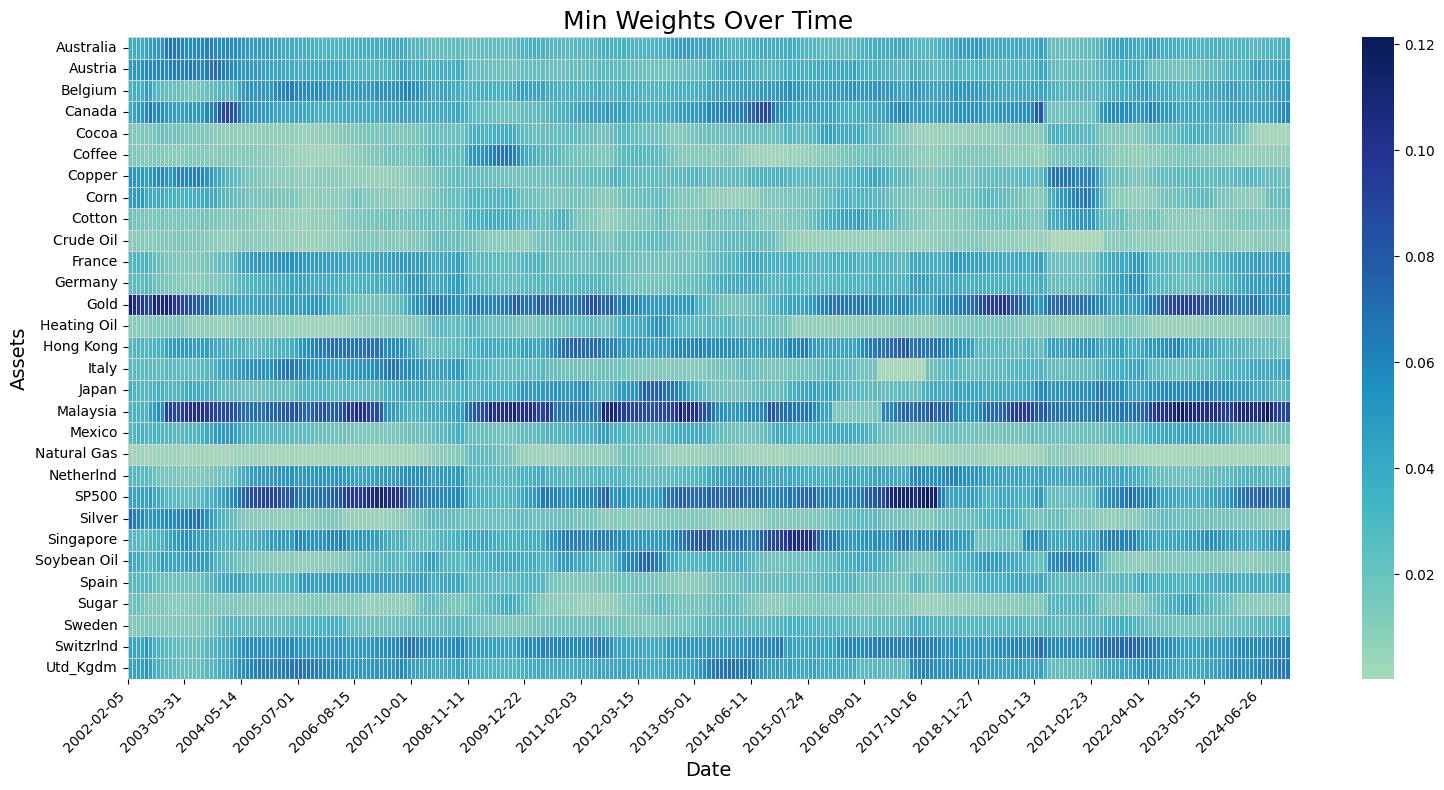

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weight_heatmap(weight_df, strategy_name='Strategy', cmap='coolwarm'):
    """
    자산별 시점별 weight를 히트맵으로 시각화하는 함수
    
    Parameters:
    - weight_df: (DataFrame) index=date, columns=assets, values=weights
    - strategy_name: (str) 전략 이름 (default: 'Strategy')
    - cmap: (str) 사용할 colormap 이름 (default: 'coolwarm')
    """
    fig, ax = plt.subplots(figsize=(16, 8))

    sns.heatmap(
        weight_df.T,
        cmap=cmap,
        cbar=True,
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax,
        center=weight_df.mean().mean()  # 중앙 기준 색상 설정
    )

    # ✅ 제목 자동 생성
    ax.set_title(f'{strategy_name} Weights Over Time', fontsize=18)
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('Assets', fontsize=14)

    # x축 날짜 표시 조정
    step = max(1, len(weight_df.index) // 20)
    selected_ticks = weight_df.index[::step]

    ax.set_xticks(range(0, len(weight_df.index), step))
    ax.set_xticklabels(selected_ticks, rotation=45, ha='right')

    # y축 자산 이름 정렬
    ax.set_yticklabels(weight_df.columns, rotation=0)

    plt.tight_layout()
    plt.show()
rp_weight = all_rp_weights.iloc[::20]
plot_weight_heatmap(rp_weight, strategy_name="Min", cmap='YlGnBu')


In [22]:
all_minvar_returns, all_minvar_weights = backtest_strategy(
    equal_return,
    compute_weights_fn=compute_minvar_weights,
    rebalance_every=rebalance_every,
    window_days=window_days,
    start_day = start_day
)

In [23]:
all_ms_returns, all_ms_weights = backtest_strategy(
    equal_return,
    compute_weights_fn=compute_max_sharpe_min_var,
    risk_free_rate=risk_free_rate,  # 무위험 수익률
    target_return=0.0,
    rebalance_every=rebalance_every,
    window_days=window_days,
    start_day = start_day


    # max_vol=0.01   # 최대 변동성 제약 (선형 근사)
)

/opt/conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


최적화 실패. 균등 포트폴리오로 fallback.
weights [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [24]:
def backtest_paa_from_pivot(returns: pd.DataFrame,
                             pivot_score: pd.DataFrame,
                             window_days: int = 252,
                             rebalance_every: int = 20,
                             top_n: int = 10,
                             score_threshold: float = 0.0,
                             cost: float = 0.003,
                             start_day: int = 252):
    """
    PAA 전략 백테스트 (수익률 기반 점수 사용, 거래비용 반영)

    Parameters:
    - returns: 일간 수익률 DataFrame (index: date, columns: tickers)
    - pivot_score: PAA score DataFrame (index: date, columns: tickers)
    - window_days: 과거 데이터 시작 시점
    - rebalance_every: 리밸런싱 주기
    - top_n: 상위 자산 수
    - score_threshold: 점수 필터링 기준
    - cost: 거래 비용 비율

    Returns:
    - paa_returns: 전략 일간 수익률 Series
    - paa_weights: 전략 리밸런싱 시점별 자산 비중 DataFrame
    """
    dates = returns.index
    portfolio_returns = []
    weights_record = []
    prev_weights = pd.Series(0, index=returns.columns, dtype=float)

    i = start_day
    while i < len(dates) - rebalance_every:
        current_date = dates[i]
        score_today = pivot_score.loc[current_date]
        satisfied_assets = score_today[score_today > score_threshold]
        if satisfied_assets.empty:
            selected = []
        else:
            selected = satisfied_assets.sort_values(ascending=False).head(top_n).index

        weights = pd.Series(0, index=returns.columns, dtype=float)
        if len(selected) > 0:
            weights[selected] = 1 / len(selected)

        if i + rebalance_every < len(dates) - rebalance_every:
            sub_returns = returns.iloc[i:i + rebalance_every]
        else:
            sub_returns = returns.iloc[i:]
                    
        for j, (date, row) in enumerate(sub_returns.iterrows()):
            tc = np.abs(weights - prev_weights).sum() * cost if j == 0 else 0
            daily_ret = np.dot(weights, row.fillna(0)) - tc
            portfolio_returns.append((date, daily_ret))
            weights_record.append((date, weights.copy()))

        prev_weights = weights.copy()
        i += rebalance_every

    paa_returns = pd.Series(dict(portfolio_returns)).sort_index()
    paa_weights = pd.DataFrame({d: w for d, w in weights_record}).T
    return paa_returns, paa_weights

In [25]:
eqaul_df.columns

Index(['date', 'tic_code', 'close', 'ticker', 'ret', 'high_ratio', 'low_ratio',
       'adjust_close', 'adjust_high', 'adjust_low', 'return_1m', 'return_3m',
       'return_6m', 'return_12m', 'return_avg', 'mom_12m', 'mom_score',
       'close_1_month', 'close_2_month', 'close_3_month', 'close_4_month',
       'close_5_month', 'close_6_month', 'close_7_month', 'close_8_month',
       'close_9_month', 'close_10_month', 'close_11_month', 'close_12_month',
       'SMA_30', 'SMA_60', 'SMA_220', 'SMA_252', 'macd', 'boll_ub', 'boll_lb',
       'rsi', 'cci', 'paa_score', 'gtaa_buy_signal', 'paa_buy_signal',
       'daa_buy_signal', 'momentum_product', 'dm_buy_signal',
       'adjust_close_norm', 'return_1m_norm', 'return_3m_norm',
       'return_6m_norm', 'return_12m_norm', 'return_avg_norm', 'mom_12m_norm',
       'mom_score_norm', 'SMA_30_norm', 'SMA_60_norm', 'SMA_220_norm',
       'SMA_252_norm', 'macd_norm', 'boll_ub_norm', 'boll_lb_norm', 'rsi_norm',
       'cci_norm'],
      dtype='obj

In [26]:
all_paa_score = eqaul_df.pivot(index='date', columns='ticker', values='paa_score')

In [27]:
all_paa_returns, all_paa_weights = backtest_paa_from_pivot(
    equal_return, all_paa_score,
    top_n=top_k,
    window_days = window_days,
    rebalance_every=rebalance_every,
    score_threshold=0.0,
    cost=0.003
)

In [28]:
def backtest_equal_weight_20day(returns: pd.DataFrame, rebalance_every=20, window_days=252, cost=0.003, start_day=252):
    dates = returns.index
    portfolio_returns = []
    weights_record = []
    prev_weights = None

    i = start_day
    while i < len(dates) - rebalance_every:
        rebalance_day = dates[i]
        window_data = returns.iloc[i - window_days:i]


        n_assets = window_data.shape[1]
        weights = np.ones(n_assets) / n_assets  # 1/N 포트폴리오
        n_assets = returns.shape[1]
        if prev_weights is None:
            prev_weights = np.zeros(n_assets)  # 최초 리밸런싱: 전량 매수로 간주
            
        if i + rebalance_every < len(dates) - rebalance_every:
            sub_returns = returns.iloc[i:i + rebalance_every]
        else:
            sub_returns = returns.iloc[i:]

        for j, (date, row) in enumerate(sub_returns.iterrows()):
            if j == 0 and prev_weights is not None:
                turnover = np.abs(weights - prev_weights).sum()
                tc = turnover * cost
            else:
                tc = 0
            daily_ret = np.dot(weights, row.fillna(0)) - tc
            portfolio_returns.append((date, daily_ret))
            weights_record.append((date, weights))

        prev_weights = weights
        i += rebalance_every

    ew_returns = pd.Series(dict(portfolio_returns)).sort_index()
    ew_weights = pd.DataFrame({d: w for d, w in weights_record}).T
    return ew_returns, ew_weights


In [29]:
equal_returns, equal_weights = backtest_equal_weight_20day(equal_return, rebalance_every=rebalance_every, window_days=window_days, cost=0.003)


In [30]:
equal_weights.columns = equal_return.columns

In [31]:
strategy_returns = {
    'risk_parity': all_rp_returns,
    'minvar': all_minvar_returns,
    'maxsharpe': all_ms_returns,
    'paa' : all_paa_returns,

    # 'index_gtaa': index_gtaa_returns,
    'Equal Weight': equal_returns
}

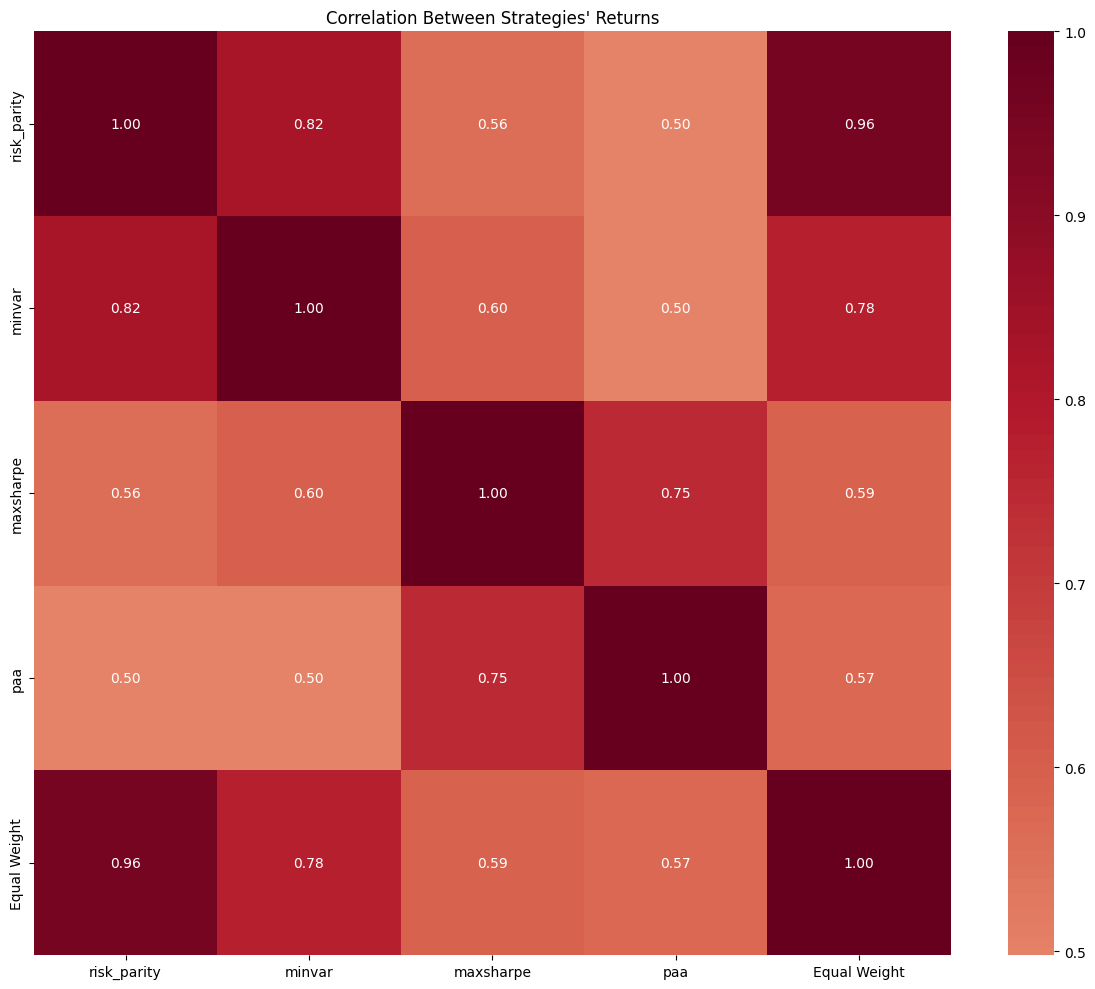

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 전략 수익률 DataFrame 생성
strategy_df = pd.DataFrame(strategy_returns)

# 2. 상관관계 행렬 계산
correlation_matrix = strategy_df.corr()

# 3. 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Between Strategies' Returns")
plt.tight_layout()
plt.show()


In [33]:
# def calculate_cagr(returns, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     cumulative_return = np.prod(1 + returns) - 1
#     years = len(returns) / annual_factor
#     return (1 + cumulative_return) ** (1 / years) - 1


def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    # 연환산 수익률과 표준편차
    return excess_return / annual_std_dev if annual_std_dev != 0 else 0.0


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cumulative_returns(returns_dict, title='Cumulative Returns Comparison', y_range=(0.0, 5), test_start_date=None):
    """
    전략별 누적 수익률 차트를 그립니다. 개별 자산은 제외하고 Equal Weight 전략은 검정색으로 표시합니다.

    Parameters:
    - returns_dict: {strategy_name: pd.Series} 구조의 전략 수익률 딕셔너리
    - title: 차트 제목
    - y_range: y축 범위 (튜플, 예: (0.9, 2.5))
    """
    plt.figure(figsize=(14, 8))

    for strategy_name, daily_returns in returns_dict.items():
        cumulative_returns = (1 + daily_returns).cumprod()
        
        if strategy_name.lower() in ['equal weight', 'equal']:
            plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
                     label=f'Strategy - {strategy_name}', color='black', linewidth=2.5)
        else:
            plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
                     label=f'Strategy - {strategy_name}', linewidth=2)
    # 테스트 시작일 수직선 추가
    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.ylim(y_range)  # Y축 고정
    plt.xticks(np.arange(0, len(cumulative_returns.index), 60),
               cumulative_returns.index.astype(str)[::60], rotation=45)
    plt.legend(loc='upper left', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [35]:
# strategy_returns = {
#     'Risk Parity': rp_returns,
#     'min-Variance': minvar_returns,
# }

In [36]:
strategy_returns.keys()

dict_keys(['risk_parity', 'minvar', 'maxsharpe', 'paa', 'Equal Weight'])

In [37]:
strategy_returns["risk_parity"].shape, strategy_returns["minvar"].shape, strategy_returns["maxsharpe"].shape, strategy_returns["paa"].shape

((5731,), (5731,), (5731,), (5731,))

In [38]:
strategy_returns["Equal Weight"].shape

(5731,)

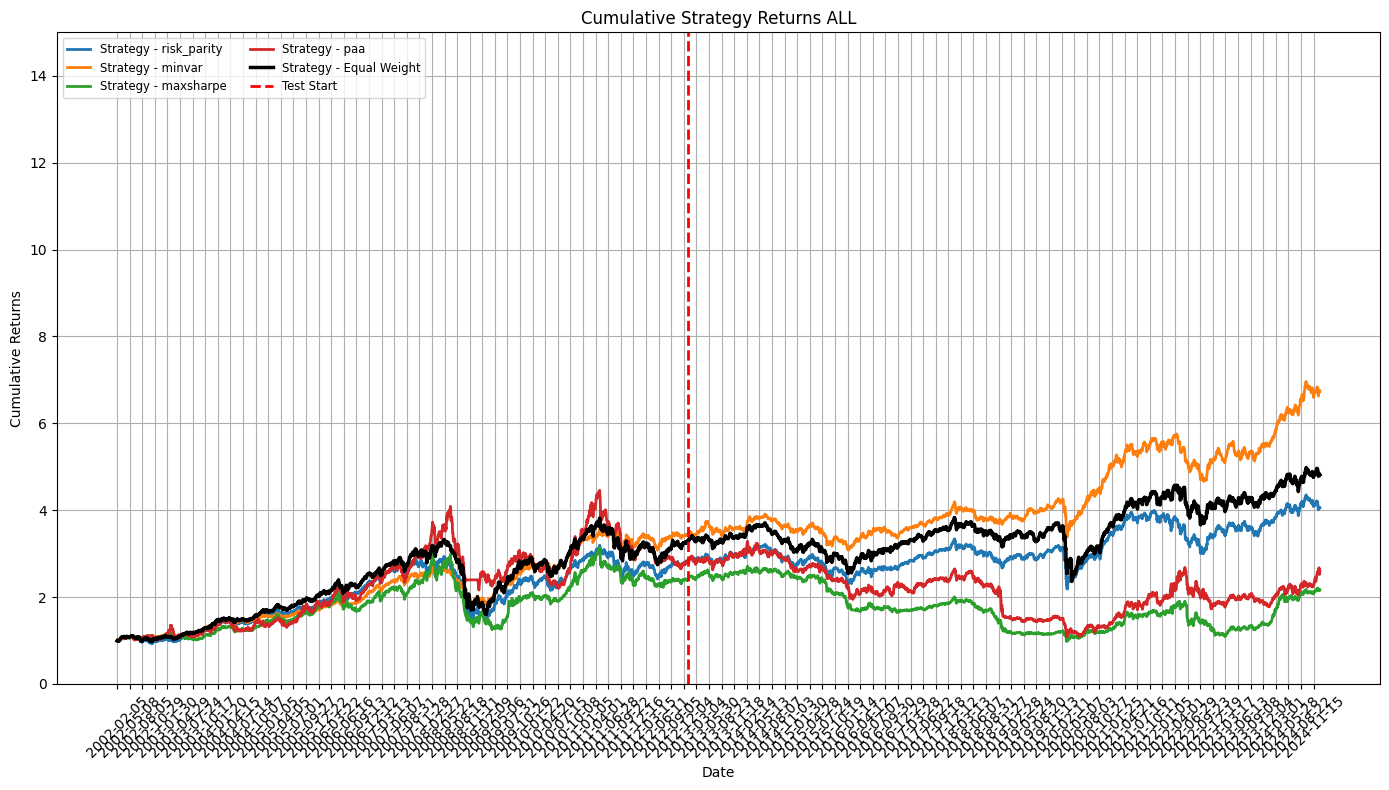

In [39]:
plot_cumulative_returns(strategy_returns, "Cumulative Strategy Returns ALL", (0.0, 15), test_start_date = "2013-01-02")

In [40]:
strategy_returns

{'risk_parity': 2002-02-05   -0.004431
 2002-02-06   -0.003447
 2002-02-07    0.002515
 2002-02-08    0.006796
 2002-02-11    0.003493
                 ...   
 2024-12-24    0.004355
 2024-12-26    0.002422
 2024-12-27   -0.002674
 2024-12-30   -0.002913
 2024-12-31    0.000422
 Length: 5731, dtype: float64,
 'minvar': 2002-02-05    0.007067
 2002-02-06   -0.000896
 2002-02-07   -0.000863
 2002-02-08    0.007633
 2002-02-11   -0.005547
                 ...   
 2024-12-24    0.004629
 2024-12-26    0.002984
 2024-12-27   -0.002529
 2024-12-30    0.002319
 2024-12-31    0.003147
 Length: 5731, dtype: float64,
 'maxsharpe': 2002-02-05   -0.007578
 2002-02-06    0.004537
 2002-02-07    0.012914
 2002-02-08    0.007345
 2002-02-11    0.007395
                 ...   
 2024-12-24    0.008166
 2024-12-26   -0.002971
 2024-12-27   -0.012299
 2024-12-30    0.004256
 2024-12-31    0.000601
 Length: 5731, dtype: float64,
 'paa': 2002-02-05   -0.000850
 2002-02-06   -0.002986
 2002-02-07    0.00334

In [41]:
metrics_summary = get_performance_summary(
    strategy_returns,
    annual_factor=252,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
risk_parity,3.050437,0.063439,0.137658,0.460848,0.517716
minvar,5.754640,0.087624,0.098399,0.890500,0.346831
maxsharpe,1.161621,0.034477,0.170528,0.202176,0.686945
paa,1.603418,0.042971,0.202794,0.211893,0.757277
Equal Weight,3.818659,0.071591,0.148739,0.481322,0.521208


In [42]:
slice_asset = equal_df.iloc[window_days:]
asset_return = slice_asset.pct_change().fillna(0)

In [43]:
asset_returns = {}
for asset in asset_return.columns:
    asset_returns[asset] = asset_return[asset]

In [44]:
import glasbey

In [45]:
asset_returns.keys()

dict_keys(['Australia', 'Austria', 'Belgium', 'Canada', 'Cocoa', 'Coffee', 'Copper', 'Corn', 'Cotton', 'Crude Oil', 'France', 'Germany', 'Gold', 'Heating Oil', 'Hong Kong', 'Italy', 'Japan', 'Malaysia', 'Mexico', 'Natural Gas', 'Netherlnd', 'SP500', 'Silver', 'Singapore', 'Soybean Oil', 'Spain', 'Sugar', 'Sweden', 'Switzrlnd', 'Utd_Kgdm'])

In [46]:
get_performance_summary(asset_returns)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
Australia,1.505907,0.041221,0.227985,0.180807,0.688921
Austria,1.788757,0.046129,0.243739,0.189256,0.768363
Belgium,0.725047,0.024265,0.212331,0.114281,0.762474
Canada,2.825190,0.060767,0.216893,0.280171,0.622848
Cocoa,7.460145,0.098444,0.325208,0.302712,0.528352
Coffee,6.129320,0.090209,0.334331,0.269819,0.715808
Copper,4.460274,0.077498,0.271100,0.285864,0.694053
Corn,1.225728,0.035807,0.291080,0.123014,0.637293
Cotton,0.833780,0.027022,0.300167,0.090023,0.774994
Crude Oil,2.577058,0.057643,0.807930,0.071347,1.258999


In [47]:
slice_asset

ticker,Australia,Austria,Belgium,Canada,Cocoa,Coffee,Copper,Corn,Cotton,Crude Oil,...,Netherlnd,SP500,Silver,Singapore,Soybean Oil,Spain,Sugar,Sweden,Switzrlnd,Utd_Kgdm
date,,,,,,,,,,,,,,,,,,,,,
2002-02-05,9.480,7.560,10.660,10.520,1380.0,44.849998,0.7300,206.00,37.299999,20.049999,...,16.280,1090.02,4.393000,11.000,15.530000,19.190,6.340000,12.500,11.880,27.800
2002-02-06,9.400,7.600,10.650,10.450,1392.0,45.099998,0.7265,206.50,37.369999,19.750000,...,16.140,1083.51,4.361000,11.140,15.650000,18.840,6.390000,12.430,11.850,27.620
2002-02-07,9.360,7.710,10.720,10.450,1439.0,44.799999,0.7350,204.25,38.139999,19.680000,...,16.250,1080.17,4.342000,10.920,15.240000,19.260,6.280000,12.490,12.080,27.940
2002-02-08,9.510,7.730,10.750,10.550,1454.0,44.549999,0.7315,205.00,38.259998,20.250000,...,16.230,1096.22,4.452000,11.020,15.450000,19.230,6.180000,12.510,12.110,27.980
2002-02-11,9.610,7.810,10.920,10.710,1479.0,43.099998,0.7255,205.25,37.459999,21.320000,...,16.480,1111.94,4.412000,11.060,15.330000,19.300,6.000000,12.780,12.240,28.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,24.295,20.923,18.418,40.467,11852.0,328.600006,4.0495,448.50,68.779999,70.099998,...,45.358,6040.04,29.974001,21.984,39.840000,31.042,19.540001,37.591,46.396,34.177
2024-12-26,24.238,21.027,18.477,40.330,11027.0,324.649994,4.0720,453.75,68.750000,69.620003,...,45.429,6037.59,30.047001,21.911,39.470001,31.151,19.260000,37.792,46.527,34.297
2024-12-27,24.086,20.956,18.429,40.259,10124.0,322.649994,4.0625,454.00,68.889999,70.599998,...,45.150,5970.84,29.655001,21.936,39.520000,31.059,19.370001,37.803,46.304,34.030


In [48]:
metrics_summary

,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
risk_parity,3.050437,0.063439,0.137658,0.460848,0.517716
minvar,5.754640,0.087624,0.098399,0.890500,0.346831
maxsharpe,1.161621,0.034477,0.170528,0.202176,0.686945
paa,1.603418,0.042971,0.202794,0.211893,0.757277
Equal Weight,3.818659,0.071591,0.148739,0.481322,0.521208


## Tangency Portfolio

In [146]:
import cvxpy as cp

# 기존 코드 구조에서 샘플링 대신 진짜 Efficient Frontier 계산으로 교체한 버전
dates = returns.index
portfolio_returns = []
weights_record = []

i = window_days
while i < len(dates) - 20:
    window_data = returns.iloc[i - window_days:i]
    if window_data.isna().sum().sum() > 0:
        i += 20
        continue

    mu = window_data.mean().values
    cov = window_data.cov().values
    n_assets = returns.shape[1]

    # Tangency 포트폴리오 계산
    w_tangency = compute_mv_weights(mu, cov, gamma=gamma)
    tangency_ret = np.dot(w_tangency, mu)
    tangency_vol = np.sqrt(np.dot(w_tangency.T, np.dot(cov, w_tangency)))
    tangency_sharpe = (tangency_ret - 0.0) / tangency_vol

    # 진짜 Efficient Frontier 계산
    frontier_returns = np.linspace(mu.min(), mu.max(), 500)
    frontier_vols = []

    for target_return in frontier_returns:
        w = cp.Variable(n_assets)
        objective = cp.Minimize(cp.quad_form(w, cov))
        constraints = [
            mu @ w == target_return,
            cp.sum(w) == 1,
            w >= 0
        ]
        prob = cp.Problem(objective, constraints)
        prob.solve()

        if w.value is not None:
            vol = np.sqrt(w.value.T @ cov @ w.value)
            frontier_vols.append(vol)
        else:
            frontier_vols.append(np.nan)

    # 각 Frontier 점의 Sharpe 비율 계산
    frontier_sharpes = (frontier_returns - 0.0) / np.array(frontier_vols)

    # 최고 Sharpe를 갖는 지점 찾기
    max_idx = np.nanargmax(frontier_sharpes)
    max_sharpe_ret = frontier_returns[max_idx]
    max_sharpe_vol = frontier_vols[max_idx]
    max_sharpe_ratio = frontier_sharpes[max_idx]


    # 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(frontier_vols, frontier_returns, label='Efficient Frontier', color='black')
    ax.scatter(tangency_vol, tangency_ret, color='red', s=200, marker='*', label='Tangency Portfolio')
    ax.scatter(max_sharpe_vol, max_sharpe_ret, color='blue', s=100, marker='o', label='Max Frontier Sharpe')

    ax.plot([0, tangency_vol], [0.0, tangency_ret], color='red', linestyle='--', label='CML')
    ax.set_title(f"True Efficient Frontier @ t={i}")
    ax.set_xlabel("Volatility")
    ax.set_ylabel("Expected Return")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"[{i}] Tangency Sharpe: {tangency_sharpe:.4f} | Max Frontier Sharpe: {max_sharpe_ratio:.4f}")

    i += 20


NameError: name 'returns' is not defined

In [147]:
import cvxpy as cp

dates = returns.index
portfolio_returns = []
weights_record = []

i = window_days
while i < len(dates) - 20:
    window_data = returns.iloc[i - window_days:i]
    if window_data.isna().sum().sum() > 0:
        i += 20
        continue

    mu = window_data.mean().values
    cov = window_data.cov().values
    n_assets = returns.shape[1]

    # Tangency 포트폴리오 계산
    w_tangency = compute_minvar_weights(mu, cov)
    tangency_ret = np.dot(w_tangency, mu)
    tangency_vol = np.sqrt(np.dot(w_tangency.T, np.dot(cov, w_tangency)))
    tangency_sharpe = (tangency_ret - 0.0) / tangency_vol

    # 진짜 Efficient Frontier 계산
    frontier_returns = np.linspace(mu.min(), mu.max(), 500)
    frontier_vols = []

    for target_return in frontier_returns:
        w = cp.Variable(n_assets)
        objective = cp.Minimize(cp.quad_form(w, cov))
        constraints = [
            mu @ w == target_return,
            cp.sum(w) == 1,
            w >= 0
        ]
        prob = cp.Problem(objective, constraints)
        prob.solve()

        if w.value is not None:
            vol = np.sqrt(w.value.T @ cov @ w.value)
            frontier_vols.append(vol)
        else:
            frontier_vols.append(np.nan)

    # 각 Frontier 점의 Sharpe 비율 계산
    frontier_sharpes = (frontier_returns - 0.0) / np.array(frontier_vols)

    # 최고 Sharpe를 갖는 지점 찾기
    max_idx = np.nanargmax(frontier_sharpes)
    max_sharpe_ret = frontier_returns[max_idx]
    max_sharpe_vol = frontier_vols[max_idx]
    max_sharpe_ratio = frontier_sharpes[max_idx]


    # 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(frontier_vols, frontier_returns, label='Efficient Frontier', color='black')
    ax.scatter(tangency_vol, tangency_ret, color='red', s=200, marker='*', label='Tangency Portfolio')
    ax.scatter(max_sharpe_vol, max_sharpe_ret, color='blue', s=100, marker='o', label='Max Frontier Sharpe')

    ax.plot([0, tangency_vol], [0.0, tangency_ret], color='red', linestyle='--', label='CML')
    ax.set_title(f"True Efficient Frontier @ t={i}")
    ax.set_xlabel("Volatility")
    ax.set_ylabel("Expected Return")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"[{i}] Tangency Sharpe: {tangency_sharpe:.4f} | Max Frontier Sharpe: {max_sharpe_ratio:.4f}")

    i += 20


NameError: name 'returns' is not defined

In [148]:
import cvxpy as cp

# 기존 코드 구조에서 샘플링 대신 진짜 Efficient Frontier 계산으로 교체한 버전
dates = returns.index
portfolio_returns = []
weights_record = []

i = window_days
while i < len(dates) - 20:
    window_data = returns.iloc[i - window_days:i]
    if window_data.isna().sum().sum() > 0:
        i += 20
        continue

    mu = window_data.mean().values
    cov = window_data.cov().values
    n_assets = returns.shape[1]

    # Tangency 포트폴리오 계산
    w_tangency = compute_max_sharpe_min_var(mu, cov, risk_free_rate=0.0)
    tangency_ret = np.dot(w_tangency, mu)
    tangency_vol = np.sqrt(np.dot(w_tangency.T, np.dot(cov, w_tangency)))
    tangency_sharpe = (tangency_ret - 0.0) / tangency_vol

    # 진짜 Efficient Frontier 계산
    frontier_returns = np.linspace(mu.min(), mu.max(), 500)
    frontier_vols = []

    for target_return in frontier_returns:
        w = cp.Variable(n_assets)
        objective = cp.Minimize(cp.quad_form(w, cov))
        constraints = [
            mu @ w == target_return,
            cp.sum(w) == 1,
            w >= 0
        ]
        prob = cp.Problem(objective, constraints)
        prob.solve()

        if w.value is not None:
            vol = np.sqrt(w.value.T @ cov @ w.value)
            frontier_vols.append(vol)
        else:
            frontier_vols.append(np.nan)

    # 각 Frontier 점의 Sharpe 비율 계산
    frontier_sharpes = (frontier_returns - 0.0) / np.array(frontier_vols)

    # 최고 Sharpe를 갖는 지점 찾기
    max_idx = np.nanargmax(frontier_sharpes)
    max_sharpe_ret = frontier_returns[max_idx]
    max_sharpe_vol = frontier_vols[max_idx]
    max_sharpe_ratio = frontier_sharpes[max_idx]


    # 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(frontier_vols, frontier_returns, label='Efficient Frontier', color='black')
    ax.scatter(tangency_vol, tangency_ret, color='red', s=200, marker='*', label='Tangency Portfolio')
    ax.scatter(max_sharpe_vol, max_sharpe_ret, color='blue', s=100, marker='o', label='Max Frontier Sharpe')

    ax.plot([0, tangency_vol], [0.0, tangency_ret], color='red', linestyle='--', label='CML')
    ax.set_title(f"True Efficient Frontier @ t={i}")
    ax.set_xlabel("Volatility")
    ax.set_ylabel("Expected Return")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"[{i}] Tangency Sharpe: {tangency_sharpe:.4f} | Max Frontier Sharpe: {max_sharpe_ratio:.4f}")

    i += 20


NameError: name 'returns' is not defined

In [149]:
metrics_summary

,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
index_risk_parity,1.938657,0.050829,0.158320,0.321052,0.617011
index_minvar,1.365286,0.040390,0.119208,0.338823,0.491437
future_risk_parity,7.683825,0.104523,0.147173,0.710208,0.472703
future_minvar,10.646486,0.119537,0.132531,0.901950,0.396269
index_paa,2.475320,0.056302,0.145651,0.386557,0.373808
future_paa,5.889434,0.088569,0.213662,0.414529,0.621110
Equal Weight,3.818659,0.071591,0.148739,0.481322,0.521208
